<h1><b>
IAU_B Semester project
</b></h1>

<h3>
Objective:
Predict oxygen saturation variable - <b>oximetry</b>
</h3>

In [43]:
import scipy
from datetime import datetime
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats

<h4>Function definitions</h4>

In [44]:
def unify_formats(dataframe, col_name):
    df_cpy = dataframe.copy(deep = True)
    format_d = {1 : "%m/%d/%Y", 2 : "%m/%d/%Y, %H:%M:%S", 3 : "%d %b %Y", 4 : "%Y-%m-%d", 5 : "%Y/%m/%d"}
    col_ind = list(df_cpy.columns).index(col_name)
    for date_row in range(len(df_cpy[col_name])):
        date_str = df_cpy.iat[date_row, col_ind]
        parsed_str = ""
        for i in range(1, len(format_d) + 1):
            try:
                parsed_str = datetime.strptime(date_str, format_d[i])
            except ValueError:
                continue
            except Exception:
                pass
            break
        if (type(parsed_str) != str):
            df_cpy.iat[date_row, col_ind] = parsed_str.strftime("%Y-%m-%d")
        else:
            df_cpy.iat[date_row, col_ind] = date_str
            
    return df_cpy
        

<h4>DataFrames initialization</h4>

In [45]:
observations = pd.read_csv("Datasets/observation.csv", sep = '\t')
#patient.csv(patients) file is corrupted and needs to be reformatted
stations = pd.read_csv("Datasets/station.csv", sep = '\t')

In [46]:
stations.columns

Index(['QoS', 'longitude', 'station', 'latitude', 'code', 'revision'], dtype='object')

<h5>
<b>Revision</b> column manifests the exact time when a station was revisioned for its condition in each record.<br>
<p>
Each patient has paid a visit and was examined during an arbitrary time, <b>registration</b> column in <b>patients</b> dataframe. And the time of patient's visit can denote the station's condition at that time, since we have a <b>stations</b> dataframe with all revision records.
<p>
If we assume the conjecture that during visiting time of each patient state of the station was the closest earliest known state in <b>stations</b> dataframe, we can acquire state of the station at that moment in time, and therefore connect <b>stations</b> and <b>patients</b> dataframes in that way.
</h5>

In [47]:
stations.head(10)

,QoS,longitude,station,latitude,code,revision
0,good,-99.32556,San Lorenzo Acopilco,19.32889,MX,"09/18/2025, 00:00:00"
1,good,59.48390,Kachkanar,58.70020,RU,2024/07/01
2,good,15.00913,Misterbianco,37.51803,IT,27 Apr 2019
3,maintenance,-91.11667,Chichicastenango,14.93333,GT,2025/01/08
4,excellent,138.31667,Suzaka,36.65000,JP,"08/02/2017, 00:00:00"
5,good,2.59753,Tchaourou,8.88649,BJ,2024/07/28
6,excellent,-91.06177,Greenville,33.41012,US,2019/03/23
7,excellent,0.93333,East Dereham,52.68333,GB,10 Jun 2021
8,good,-68.30000,Ushuaia,-54.80000,AR,18 Dec 2016
9,good,15.28318,Brazzaville,-4.26613,CG,"03/04/2024, 00:00:00"


In [48]:
stations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 744 entries, 0 to 743
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   QoS        744 non-null    object 
 1   longitude  744 non-null    float64
 2   station    744 non-null    object 
 3   latitude   744 non-null    float64
 4   code       744 non-null    object 
 5   revision   744 non-null    object 
dtypes: float64(2), object(4)
memory usage: 35.0+ KB


In [49]:
stations.station.nunique() == stations.station.count()

np.False_

<h5>
Rows in <b>stations</b> dataframe can be grouped based on the <b>station</b> and <b>QoS</b> columns: each unique station name can be taken as an anchor towards which QoS records are gathered. 
<p>Afterwards average of all the records of every unique station's group regarding <b>QoS</b> column can be taken. <small><small><small>(Since we don't know whether we can merge <b>patients</b> dataframe with the rest of dataframes, this is considered a possibility)</small></small></small>
<p>
Before averaging QoS values, all categorical ordinal values must be mapped onto numbers.
</h5>

In [50]:
stations.QoS.unique()

array(['good', 'maintenance', 'excellent', 'acceptable'], dtype=object)

QoS unique values' mappings:<br>
maintenance - 0<br>
acceptable - 1<br>
good - 2<br>
excellent - 3

In [51]:
stations["QoS"] = stations["QoS"].map({"maintenance" : 0, "acceptable" : 1, "good" : 2, "excellent" : 3})

In [52]:
# dataframe.index returns a Series type attribute of dataframe (a Series of all index names)
#dataframe.columns returns a Series type attribute of dataframe (a Series of all column names)

# any(axis = 0/1) - returns true if iterable at least one element in that iterable is true
# sum(axis = 0/1) - returns number of true values in an array

#to create an empty column use empty Series - "" and index series of the current dataset 

# set_index - make a series of data, typically column an index 
# reset_index - remove the current index and make it a column, works for MultiDimentional indices
#stack uses both indices and columns of the current dataframe to make from both of them indices
# unstack - lets you create a table entirely from columns. One column is going to be an index 
# another is going to be a column, and other are gonna be values. Just need to look at it from left to right.
#      c1 c2 c3 c4 c5...
# ind1 v1 t1 vv1 vv2 vv3...
# ind2 v2 t2 vv7 vv8 vv9...
# ind3 v3 t3 vv11 vv15 vv18...
# ind4 v4 t4 vv12 vv4 vv5...
# ind5 v5 t5 vv20 vv6 vv19...

# c1 - column 1
# c2 - column 2
# ...
# ind1 - index 1
# ind2 - index 2
# ...

# v1, t1, vvk - values of the dataframe, k is (1 - 50)

# c1 will become index
# c2 will become column
# and all other will become their values

# So: v1 - index; t1 - column; vv1 - value
# So: v1 - index; t2 - column; vv2 - value
# So: v1 - index; t3 - column; vv3 - value
# and so on

# pivot works similarly
# but there you can explicitly set "index" column and "column" column 

# dataframe.groupby("column").aggregate("sum") - sums values of each column's group is possible

# columns can be selected using dataframe.rename(columns = {"old_name": "new_name", ...})

# isnull(), alias for isna() returns the same sized array of boolean values, at each position indicating true or false, correspodingly Nan, None, np.nan value or not

# dataframe[dataframe['column_name'].isnull()] - selection of rows where there are empty values

#notnull() is alias for notna() is a function that returns for a Series of data the same sized array wih boolean values denoting whether value is true or not


In [53]:
# QoS_av = stations.groupby("station")["QoS"].mean()
# qos_avl = list(QoS_av)
# for val in qos_avl:
#     QoS_av.iloc[qos_avl.index(val)] = round(val)
# QoS_av = pd.DataFrame(QoS_av.astype(int))
# # QoS_av = pd.DataFrame(QoS_av.astype(int)).reset_index() #converts indeices' values into a single column


In [54]:
# stations.drop(labels = "QoS", axis = "columns", inplace = True)
# stations = stations.drop_duplicates()

# stations

In [55]:
# stations = stations.join(QoS_av, lsuffix = "_l", rsuffix = "_r", how = "inner", on = ["station"])
# # stations = pd.merge(left = stations, right = QoS_av, how = "left", left_on = "station", right_on = "station")

In [56]:

# col_ind = list(formatted.columns).index("revision")
# str_counter = 0
# dt_counter = 0
# for k in range(len(formatted.revision)):
#     if (type(formatted.iat[k, col_ind]) == str):
#        str_counter += 1
#     else:
#         dt_counter += 1
#     print(type(formatted.iat[k, col_ind]))
# print(f"{dt_counter} - dt; {str_counter} - str")

In [57]:
# nuv_pc = observations.nunique(axis = 0)

# su_n = [ind for ind, val in enumerate(nuv_pc) if ((list(observations.columns)[ind] != "oximetry") and (val/len(observations) < 0.05))]

# observations.iloc[:, 21]
# print(observations.columns[22])
# # su_n[:, 22]

<h4>
Using <b>longitude</b> and <b>latitude</b> columns both <b>observations</b> and <b>stations</b> dataframes can be merged into one dataframe <b>main_df</b>. Of course if we have all unique records in <b>stations</b> dataframe
</h4>

SpO₂ - Peripheral oxygen saturation | (95–100%)<br>
HR - Heart rate from pulse oximeter | (60–100 bpm)<br>
PI - Perfusion index | (0.2–20%)<br>
RR - Respiratory rate | (12–20 breaths/min)<br>
EtCO₂ - End-tidal carbon dioxide | (35–45 mmHg)<br>
FiO₂ - Fraction of inspired oxygen | (21–100%)<br>
PRV - Pulse rate variability | (20–200 ms)<br>
BP - Blood pressure (systolic diastolic mean) | (90/60–120/80 mmHg)<br>
Skin Temperature - Peripheral temperature | (33–38 °C)<br>
Motion/Activity index - Sensor artifact correction | (Relative units)<br>
PVI - Pleth Variability Index | (10–20%)<br>
Hb level - Hemoglobin concentration | (12–18 g/dL)<br>
SV - Stroke volume | (60–100 mL/beat)<br>
CO - Cardiac output | (4–8 L/min)<br>
Blood Flow Index - Optical/near-infrared blood flow measurement | (Relative units)<br>
PPG waveform features - Photoplethysmography signal parameters | (Relative units)<br>
Signal Quality Index - Reliability indicator of readings | (0–100)<br>
Respiratory effort - Chest impedance or belt-derived effort | (Relative units)<br>
O₂ extraction ratio - Calculated oxygen extraction metric | (0.2–0.3)<br>
SNR - Signal-to-noise ratio from sensor | (20–40 dB)

In [58]:
dup_observ = observations.duplicated(keep = "first")
print(dup_observ.any().sum())
observations.drop_duplicates(inplace = True)


1


In [59]:
def remove_outliers(dataframe, column_name, method = 1):
    purg_series = dataframe[column_name]
    bottom_bound = purg_series.quantile(0.25) - 1.5 * stats.iqr(purg_series)
    top_bound =  purg_series.quantile(0.75) + 1.5 * stats.iqr(purg_series)
    if (method == 1):
        dataframe = dataframe[(purg_series >= bottom_bound) & (purg_series <= top_bound)]
    else:
        dataframe[column_name] = np.where(purg_series > top_bound, purg_series.quantile(0.95), np.where(purg_series < bottom_bound, purg_series.quantile(0.05), purg_series))
    
    return dataframe

['SpO₂', 'RR', 'Skin Temperature', 'PVI', 'Hb level']


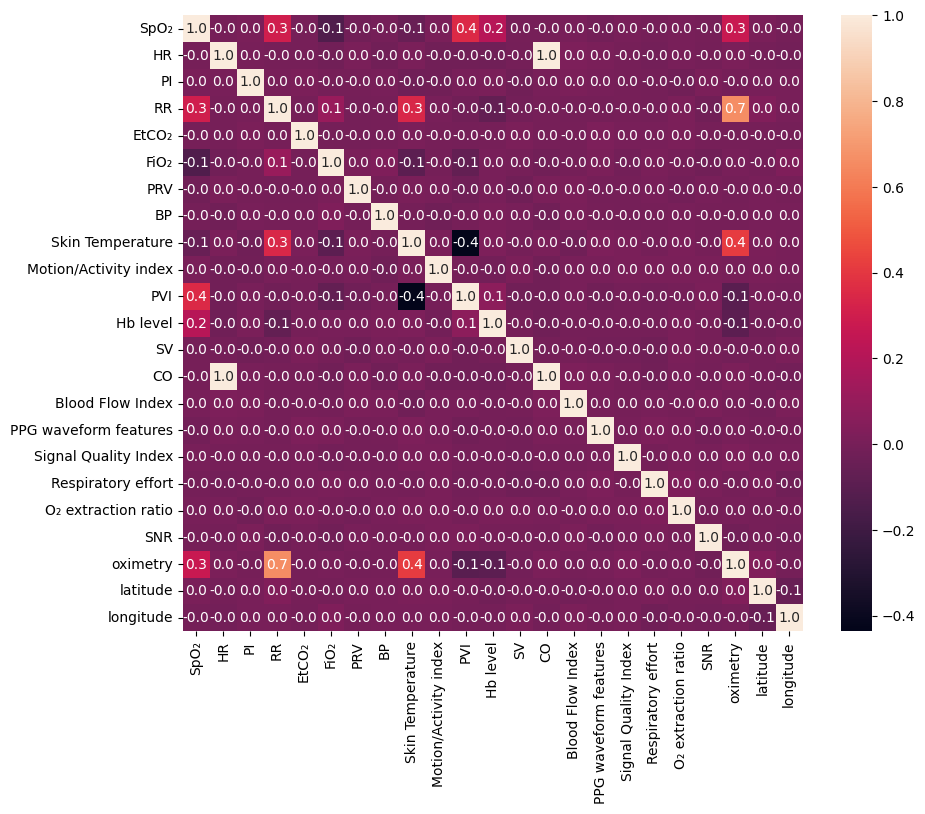

In [60]:
# correlation_matrix = observations.corr(method = "spearman", numeric_only = True)
# sns.heatmap(correlation_matrix, ax=ax, annot=True, fmt = '.1f')

for col in list(observations.columns):
    if (col != "oximetry"):
        observations = remove_outliers(observations, col)

correlation_matrix = observations.corr(method = "spearman", numeric_only = True)
fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(correlation_matrix, ax=ax, annot=True, fmt = '.1f')

possible_attributes = []
# print(correlation_matrix[abs(correlation_matrix["oximetry"]) >= 0.3]["oximetry"])
for k in list(observations.columns):
    if (k != "oximetry"):
        r, p = scipy.stats.pointbiserialr(observations["oximetry"], observations[k])
        if (p < 0.05/22):
            possible_attributes.append(k)
print(possible_attributes)
# for k in range(len(observations)):
    

In [445]:
scipy.stats.anderson(observations["RR"], dist = "norm")

AndersonResult(statistic=np.float64(88.2876777754027), critical_values=array([0.576, 0.656, 0.787, 0.918, 1.092]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(16.545741393063434), scale=np.float64(1.2891300613604306))
 success: True
 message: '`anderson` successfully fit the distribution to the data.')

<Axes: ylabel='Frequency'>

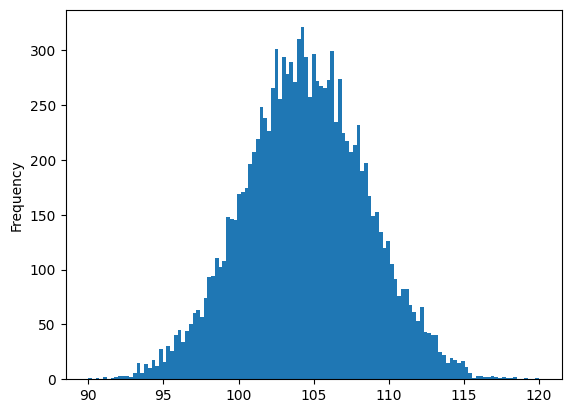

In [446]:
observations["BP"].plot(kind = "hist", bins = int(observations.index.notna().sum() / 100))

<Axes: ylabel='Frequency'>

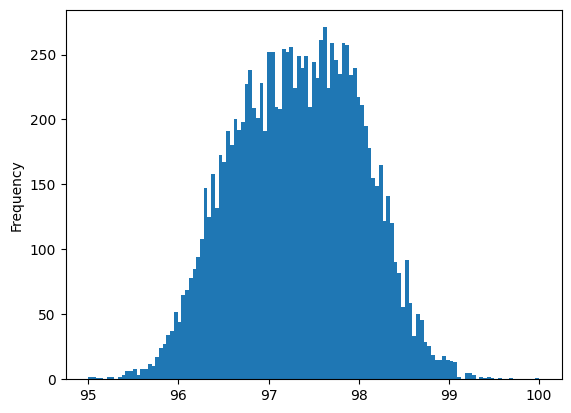

In [447]:
observations["SpO₂"].plot(kind = "hist", bins = int(observations.index.notna().sum() / 100))

<Axes: ylabel='Frequency'>

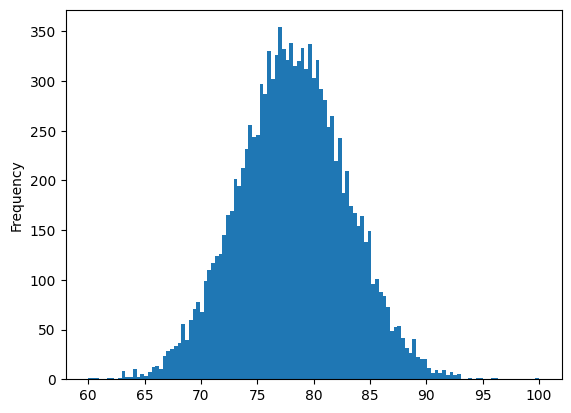

In [448]:
observations["HR"].plot(kind = "hist", bins = int(observations.index.notna().sum() / 100))

<Axes: ylabel='Frequency'>

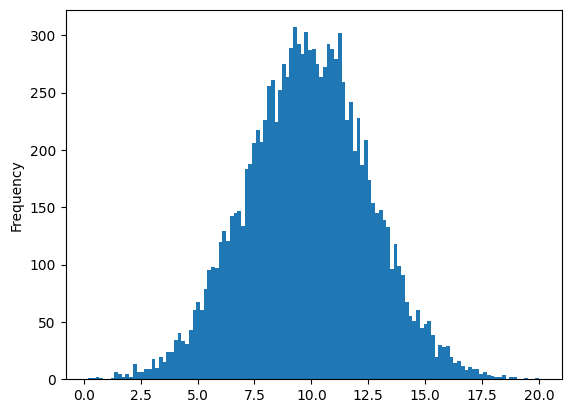

In [449]:
observations["PI"].plot(kind = "hist", bins = int(len(observations.index) / 100))

<Axes: ylabel='Frequency'>

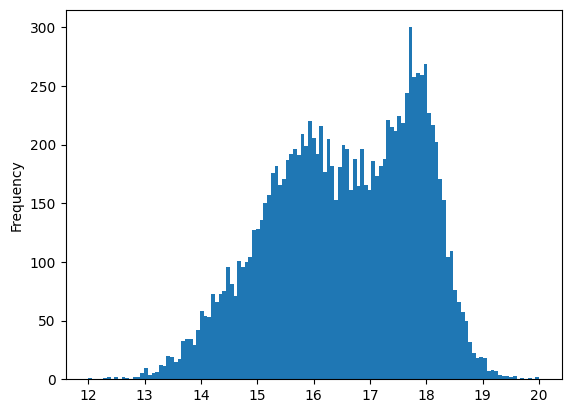

In [450]:
observations["RR"].plot(kind = "hist",  bins = int(len(observations.index) / 100))

<Axes: ylabel='Frequency'>

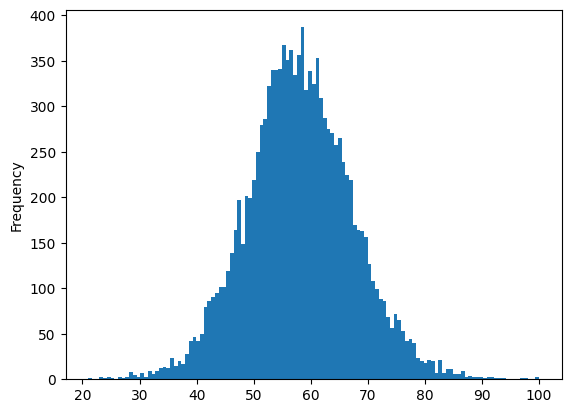

In [451]:
observations["FiO₂"].plot(kind = "hist",  bins = int(len(observations.index) / 100))

<Axes: ylabel='Frequency'>

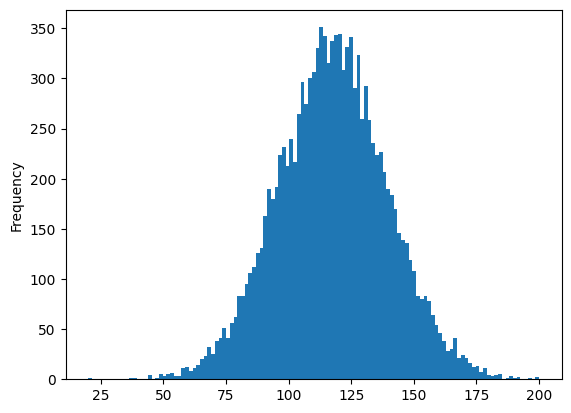

In [452]:
observations["PRV"].plot(kind = "hist",  bins = int(len(observations.index) / 100))

In [453]:
observations.columns

Index(['SpO₂', 'HR', 'PI', 'RR', 'EtCO₂', 'FiO₂', 'PRV', 'BP',
       'Skin Temperature', 'Motion/Activity index', 'PVI', 'Hb level', 'SV',
       'CO', 'Blood Flow Index', 'PPG waveform features',
       'Signal Quality Index', 'Respiratory effort', 'O₂ extraction ratio',
       'SNR', 'oximetry', 'latitude', 'longitude'],
      dtype='object')

In [454]:
observations.head(10)

,SpO₂,HR,PI,RR,EtCO₂,FiO₂,PRV,BP,Skin Temperature,Motion/Activity index,...,CO,Blood Flow Index,PPG waveform features,Signal Quality Index,Respiratory effort,O₂ extraction ratio,SNR,oximetry,latitude,longitude
0,96.615321,66.240820,10.877068,15.668587,39.658243,68.389223,96.163913,100.816532,35.751151,12.129743,...,4.002266,47.010676,54.479165,41.743618,50.708816,0.259091,39.107576,0.0,53.60520,10.03988
1,97.857755,71.825379,8.921403,16.552066,40.874901,44.950264,120.131860,93.114821,36.615192,10.568549,...,4.010066,57.466919,42.151782,40.852335,36.853826,0.240683,25.113412,1.0,43.78956,7.60872
2,96.631890,92.036880,12.541174,15.618439,41.920327,56.997064,169.416508,106.999465,36.103454,10.990277,...,4.758854,50.900908,67.493365,25.994388,54.595833,0.296654,39.118661,0.0,-30.60106,-71.19901
3,96.265996,83.376581,6.962895,16.484031,40.268000,65.845402,144.168855,102.421032,36.896469,10.852268,...,4.123592,34.585783,64.340739,52.661503,52.678544,0.234541,21.987564,1.0,51.26000,-2.18750
4,98.496281,82.390453,16.397518,14.534631,39.147657,60.595273,94.984050,104.124699,35.115265,11.262360,...,4.100501,75.665416,45.108028,58.489321,54.935624,0.267257,34.891072,0.0,26.11527,86.59509
5,96.330910,76.617920,10.412687,16.889530,41.355032,57.741858,114.410769,104.707593,36.396458,11.336398,...,4.029392,63.262210,68.080618,48.121800,63.196636,0.233605,39.991586,1.0,25.66795,85.83636
6,97.595834,78.301725,15.462197,17.065530,37.463782,41.176474,100.215125,110.813358,35.140425,10.171594,...,4.042651,46.892422,79.729045,65.389923,46.075430,0.231257,20.766937,1.0,46.08333,122.08333
7,98.463297,72.878802,12.763392,18.037806,39.886221,50.664259,95.064514,99.241748,34.899798,12.360385,...,4.013478,51.518070,65.835808,56.801196,53.196426,0.262041,26.167014,1.0,29.84576,-90.10674
8,97.432293,82.641851,14.817164,17.364814,39.500075,74.594883,142.093294,98.841377,35.482710,9.854858,...,4.106633,57.206774,42.193790,55.740796,34.283392,0.252197,28.511744,0.0,-15.21194,-75.11028
9,96.941706,86.432272,10.652708,14.785924,40.016469,73.544954,119.147138,105.916782,35.708927,13.814392,...,4.235275,41.039619,51.300838,67.492767,51.629568,0.256821,36.400370,0.0,-19.72806,-50.19556


In [455]:
observations.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12134 entries, 0 to 12134
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   SpO₂                   12134 non-null  float64
 1   HR                     12134 non-null  float64
 2   PI                     12134 non-null  float64
 3   RR                     12134 non-null  float64
 4   EtCO₂                  12134 non-null  float64
 5   FiO₂                   12134 non-null  float64
 6   PRV                    12134 non-null  float64
 7   BP                     12134 non-null  float64
 8   Skin Temperature       12134 non-null  float64
 9   Motion/Activity index  12134 non-null  float64
 10  PVI                    12134 non-null  float64
 11  Hb level               12134 non-null  float64
 12  SV                     12134 non-null  float64
 13  CO                     12134 non-null  float64
 14  Blood Flow Index       12134 non-null  float64
 15  PPG wav

In [456]:
observations.describe([0.25, 0.35, 0.65, 0.75, 0.95])

,SpO₂,HR,PI,RR,EtCO₂,FiO₂,PRV,BP,Skin Temperature,Motion/Activity index,...,CO,Blood Flow Index,PPG waveform features,Signal Quality Index,Respiratory effort,O₂ extraction ratio,SNR,oximetry,latitude,longitude
count,12134.000000,12134.000000,12134.000000,12134.000000,12134.000000,12134.000000,12134.000000,12134.000000,12134.000000,12134.000000,...,12134.000000,12134.000000,12134.000000,12134.000000,12134.000000,12134.000000,12134.000000,12134.000000,12134.000000,12134.000000
mean,97.330942,78.143398,9.833015,16.545741,39.851116,58.057890,117.646825,104.446310,35.865320,11.240041,...,4.068189,52.718122,50.468767,50.409746,48.897267,0.249560,29.986724,0.596588,29.972679,8.563294
std,0.699143,4.787882,2.700286,1.289130,1.239846,9.285435,21.834414,4.082615,0.798653,0.995788,...,0.094288,13.647706,12.855059,13.596986,11.785054,0.028918,5.764169,0.490602,22.525365,74.145323
min,95.000000,60.000000,0.200000,12.000000,35.000000,21.000000,20.000000,90.000000,33.000000,7.252493,...,4.000000,0.000000,0.000000,0.000000,0.000000,0.200000,20.000000,0.000000,-54.800000,-123.026210
25%,96.799852,74.938167,8.019433,15.587033,39.014800,52.126341,103.054709,101.696980,35.271645,10.579505,...,4.020595,43.372162,41.780939,41.125317,41.000804,0.224573,24.970796,0.000000,15.728920,-69.083330
35%,97.028820,76.288572,8.818643,15.984602,39.369789,54.511399,109.543234,102.843769,35.595167,10.860372,...,4.027597,47.466584,45.477821,45.090643,44.398236,0.234547,26.998744,0.000000,27.475330,-2.187500
50%,97.345567,78.123651,9.844198,16.615931,39.849445,57.882151,117.642846,104.400497,35.976598,11.240815,...,4.040852,52.665950,50.281761,50.512569,48.915150,0.249142,30.078329,1.000000,37.197230,8.963170
65%,97.655509,79.967319,10.914536,17.295056,40.328324,61.320701,125.799325,106.041521,36.297173,11.625709,...,4.060408,57.886849,55.436624,55.617929,53.312887,0.264216,33.027926,1.000000,42.833400,31.497600
75%,97.857739,81.355542,11.641095,17.658583,40.690167,64.046254,132.100836,107.211673,36.482329,11.909819,...,4.081064,61.849797,59.225467,59.551417,56.728364,0.274706,34.954700,1.000000,47.050000,71.211690
95%,98.428909,85.995160,14.220539,18.351319,41.891841,73.517957,153.971805,111.267389,37.004002,12.873370,...,4.214576,75.415224,71.582200,72.947633,68.390925,0.294893,38.954790,1.000000,53.593370,127.084720


Latitude and longitude would be used to join observations and stations datasets, since in observations longitude and latitude represent location of the station where each observation was conducted. 
<br>
Later on patients can be joined with the resulting dataframe on station_ID feature.

In [457]:
main_df = pd.merge(left_on = ["longitude", "latitude"], right_on = ["longitude", "latitude"], how = "left", left = observations, right = stations)

In [458]:
main_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21684 entries, 0 to 21683
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   SpO₂                   21684 non-null  float64
 1   HR                     21684 non-null  float64
 2   PI                     21684 non-null  float64
 3   RR                     21684 non-null  float64
 4   EtCO₂                  21684 non-null  float64
 5   FiO₂                   21684 non-null  float64
 6   PRV                    21684 non-null  float64
 7   BP                     21684 non-null  float64
 8   Skin Temperature       21684 non-null  float64
 9   Motion/Activity index  21684 non-null  float64
 10  PVI                    21684 non-null  float64
 11  Hb level               21684 non-null  float64
 12  SV                     21684 non-null  float64
 13  CO                     21684 non-null  float64
 14  Blood Flow Index       21684 non-null  float64
 15  PP

In [459]:
main_df.head(5)

,SpO₂,HR,PI,RR,EtCO₂,FiO₂,PRV,BP,Skin Temperature,Motion/Activity index,...,Respiratory effort,O₂ extraction ratio,SNR,oximetry,latitude,longitude,QoS,station,code,revision
0,96.615321,66.240820,10.877068,15.668587,39.658243,68.389223,96.163913,100.816532,35.751151,12.129743,...,50.708816,0.259091,39.107576,0.0,53.60520,10.03988,2,Barmbek-Nord,DE,"11/11/2015, 00:00:00"
1,97.857755,71.825379,8.921403,16.552066,40.874901,44.950264,120.131860,93.114821,36.615192,10.568549,...,36.853826,0.240683,25.113412,1.0,43.78956,7.60872,2,Ventimiglia,IT,2021-05-13
2,96.631890,92.036880,12.541174,15.618439,41.920327,56.997064,169.416508,106.999465,36.103454,10.990277,...,54.595833,0.296654,39.118661,0.0,-30.60106,-71.19901,0,Ovalle,CL,"03/07/2016, 00:00:00"
3,96.631890,92.036880,12.541174,15.618439,41.920327,56.997064,169.416508,106.999465,36.103454,10.990277,...,54.595833,0.296654,39.118661,0.0,-30.60106,-71.19901,3,Ovalle,CL,"03/29/2020, 00:00:00"
4,96.265996,83.376581,6.962895,16.484031,40.268000,65.845402,144.168855,102.421032,36.896469,10.852268,...,52.678544,0.234541,21.987564,1.0,51.26000,-2.18750,1,Westbury,GB,2019/10/05


In [460]:
main_df["oximetry"].value_counts(normalize = True)

oximetry
1.0    0.595693
0.0    0.404307
Name: proportion, dtype: float64

In [461]:
main_df.drop(columns = ["code"], axis = 1, inplace = True)# No need for nominal categorical type of data, additionally if there's any correlation 
# or even causation it would be with longtitude and latitude, both of which represent station and code features


In [462]:
file = open("Datasets/patient.csv", "r", encoding="utf-8")
parsed_file = open("Datasets/patient_redacted.csv", "w")

columns = ["registration", "latitude", "longitude", "birthdate", "ssn", "mail", "blood_group", "station_ID"]
parsed_file.write(";".join(columns) + "\n")
new_lines = list()
lines = file.readlines()
del lines[0]

line_ctr = -1
for line in lines:
    if (line[0].isspace()):
        new_lines.append(line.strip() + "\n")
        line_ctr += 1
    else:
        new_lines[line_ctr] = new_lines[line_ctr].strip() + " " + line

del lines

for index in range(line_ctr):
    nc_line = new_lines[index]
    location = re.findall("\(Decimal\('.*?'\),\sDecimal\('.*?'\)\)", nc_line)
    loc_pos = re.search("\(Decimal\('.*?'\),\sDecimal\('.*?'\)\)", nc_line)
    dates = re.findall("((?:^|\s+?)(?:\d{4}[./-]\d{2}[./-]\d{2}|\d{2} \w{3} \d{4}|(?:\d{2}/){2}\d{4}(?:,\s(?:\d{2}:){2}\d{2})?)\s+?)", nc_line)

    
    #\s*(?:\d{4}[./-]\d{2}[./-]\d{2}|\d{2} \w{3} \d{4}|(?:\d{2}/){2}\d{4}(?:,\s(?:\d{2}:){2}\d{2})?)\s - older version for whole
    date_pos = re.search("((?:^|\s+?)(?:\d{4}[./-]\d{2}[./-]\d{2}|\d{2} \w{3} \d{4}|(?:\d{2}/){2}\d{4}(?:,\s(?:\d{2}:){2}\d{2})?)\s+?)", nc_line)
    ssn = re.findall("(?:[A-Z0-9]{16}|\d{3}-\d{2}-\d{4}|\d{11})", nc_line)
    ssn_pos = re.search("([A-Z0-9]{16})|(\d{3}-\d{2}-\d{4})|(\d{11})", nc_line)
    mail = re.findall("[\d\w.]+@[\d\w.]+", nc_line)
    blood_group = re.findall("[ABO]{1,2}[+-]", nc_line)
    station_ID = re.findall("\d{1,3}\n", nc_line)
    longitude = None
    latitude = None
    
    if(loc_pos == None):
        location = None
    else:
        location = re.match("\(Decimal\('(?P<latitude>.*?)'\),\sDecimal\('(?P<longitude>.*?)'\)\)", location[0])
        longitude = location["longitude"]
        latitude = location["latitude"]
    
    ssn = None if(ssn_pos == None) else ssn[0]
    mail = None if(len(mail) == 0) else mail[0]
    blood_group = None if(len(blood_group) == 0) else blood_group[0]
    station_ID = None if(len(station_ID) == 0) else station_ID[0].strip()
    
    if(len(dates) > 1):
        registration = dates[0].strip()
        birthdate = dates[1].strip()
    elif(date_pos != None):
        if(re.match("((?:^|\s+?)(?:\d{4}/\d{2}/\d{2}|\d{2} \w{3} \d{4}|(?:\d{2}/){2}\d{4}(?:,\s(?:\d{2}:){2}\d{2})?)\s+?)", dates[0]) != None):
            registration = dates[0].strip()
            birthdate = None
        elif(location != None):
            if(date_pos.start() < loc_pos.start()):
                registration = dates[0].strip()
                birthdate = None
            else:
                birthdate = dates[0].strip()
                registration = None
    else:
        registration = None
        birthdate = None
        
    # if (mail == "wantonini@tele2.it"):
    #     print(f"<{nc_line}> - line")
    #     print(f"{location} - loc\n{dates} - dates\n{date_pos} - date_pos\n{ssn} - ssn\n{ssn} - ssn_pos\n{mail} - mail\n{blood_group} - blood_group\n{station_ID} - station_ID\n{registration} - reg\n{birthdate} - birth")
        
    # print(f"<{registration};{latitude};{longitude};{birthdate};{ssn};{mail};{blood_group};{station_ID}> - line")
    parsed_file.write(f"{registration};{latitude};{longitude};{birthdate};{ssn};{mail};{blood_group};{station_ID}\n")

    
    

In [463]:
patients = pd.read_csv("Datasets/patient_redacted.csv", sep = ";")
patients

,registration,latitude,longitude,birthdate,ssn,mail,blood_group,station_ID
0,28 Sep 2020,-80.004689,37.669680,1966-05-04,TGLMTT84A52G804H,isabella08@tiscali.it,AB-,316
1,2019-12-04,50.103476,150.889543,NaN,TMBLVR61M27C821K,mirko95@vodafone.it,A+,482
2,2020-12-06,68.767255,-51.583432,NaN,323-46-6887,roemertassilo@googlemail.com,B-,510
3,21 Jun 2021,80.373267,-64.664433,NaN,319-42-4326,jopichlaszlo@gmx.de,AB-,398
4,"07/23/2019, 00:00:00",-48.825258,-43.424063,1916-05-23,38719056400,procha@bol.com.br,A-,432
...,...,...,...,...,...,...,...,...
2150,2022/10/18,44.242252,20.763877,NaN,92456817346,sampaioyasmin@gmail.com,O-,37
2151,2022/02/13,8.362272,-125.249855,NaN,56973012868,ryan55@uol.com.br,B+,324
2152,2022/03/07,-3.387962,76.949840,NaN,193-43-4596,petra19@aol.de,B-,227
2153,21 Aug 2025,-55.178508,75.690947,1969-11-06,122-16-3647,elenabender@yahoo.de,A-,436


In [467]:
formatted = unify_formats(patients, "registration")
formatted.to_csv("formatted.csv", index = False, sep = ";")

In [468]:
formatted

,registration,latitude,longitude,birthdate,ssn,mail,blood_group,station_ID
0,2020-09-28,-80.004689,37.669680,1966-05-04,TGLMTT84A52G804H,isabella08@tiscali.it,AB-,316
1,2019-12-04,50.103476,150.889543,NaN,TMBLVR61M27C821K,mirko95@vodafone.it,A+,482
2,2020-12-06,68.767255,-51.583432,NaN,323-46-6887,roemertassilo@googlemail.com,B-,510
3,2021-06-21,80.373267,-64.664433,NaN,319-42-4326,jopichlaszlo@gmx.de,AB-,398
4,2019-07-23,-48.825258,-43.424063,1916-05-23,38719056400,procha@bol.com.br,A-,432
...,...,...,...,...,...,...,...,...
2150,2022-10-18,44.242252,20.763877,NaN,92456817346,sampaioyasmin@gmail.com,O-,37
2151,2022-02-13,8.362272,-125.249855,NaN,56973012868,ryan55@uol.com.br,B+,324
2152,2022-03-07,-3.387962,76.949840,NaN,193-43-4596,petra19@aol.de,B-,227
2153,2025-08-21,-55.178508,75.690947,1969-11-06,122-16-3647,elenabender@yahoo.de,A-,436


In [ ]:
patients.station_ID.nunique()

692

In [ ]:
observations.drop_duplicates()

,SpO₂,HR,PI,RR,EtCO₂,FiO₂,PRV,BP,Skin Temperature,Motion/Activity index,...,CO,Blood Flow Index,PPG waveform features,Signal Quality Index,Respiratory effort,O₂ extraction ratio,SNR,oximetry,latitude,longitude
0,96.615321,66.240820,10.877068,15.668587,39.658243,68.389223,96.163913,100.816532,35.751151,12.129743,...,4.002266,47.010676,54.479165,41.743618,50.708816,0.259091,39.107576,0.0,53.60520,10.03988
1,97.857755,71.825379,8.921403,16.552066,40.874901,44.950264,120.131860,93.114821,36.615192,10.568549,...,4.010066,57.466919,42.151782,40.852335,36.853826,0.240683,25.113412,1.0,43.78956,7.60872
2,96.631890,92.036880,12.541174,15.618439,41.920327,56.997064,169.416508,106.999465,36.103454,10.990277,...,4.758854,50.900908,67.493365,25.994388,54.595833,0.296654,39.118661,0.0,-30.60106,-71.19901
3,96.265996,83.376581,6.962895,16.484031,40.268000,65.845402,144.168855,102.421032,36.896469,10.852268,...,4.123592,34.585783,64.340739,52.661503,52.678544,0.234541,21.987564,1.0,51.26000,-2.18750
4,98.496281,82.390453,16.397518,14.534631,39.147657,60.595273,94.984050,104.124699,35.115265,11.262360,...,4.100501,75.665416,45.108028,58.489321,54.935624,0.267257,34.891072,0.0,26.11527,86.59509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12130,97.385205,78.466039,13.349946,16.965079,39.771876,65.804506,125.231169,101.359033,35.925456,11.381142,...,4.043600,63.955049,62.704268,54.052104,36.885416,0.215833,37.802841,0.0,14.08230,98.19151
12131,96.930364,65.658406,11.212824,16.809527,38.855673,54.344864,127.384993,96.997014,36.260074,11.105850,...,4.002268,42.773740,58.200613,42.130057,51.738050,0.291330,21.791978,1.0,33.41012,-91.06177
12132,97.150812,72.491221,11.295314,17.996657,41.619844,52.582024,105.552984,110.866776,36.320781,9.961450,...,4.012385,41.823153,33.807926,54.432173,53.776058,0.210734,24.210105,1.0,-10.33333,39.28333
12133,96.715396,77.256318,15.914116,17.622823,39.353100,62.014037,116.798968,101.787271,36.629434,9.621106,...,4.033931,55.404543,20.146844,54.464593,29.602455,0.248375,20.018617,1.0,46.13510,-60.18310


In [ ]:
main_df = pd.merge(left_on = ["revision"], right_on = ["registration"], how = "inner", left = main_df, right = patients)

In [ ]:
main_df

,SpO₂,HR,PI,RR,EtCO₂,FiO₂,PRV,BP,Skin Temperature,Motion/Activity index,...,station,revision,registration,latitude_y,longitude_y,birthdate,ssn,mail,blood_group,station_ID
0,96.265996,83.376581,6.962895,16.484031,40.268000,65.845402,144.168855,102.421032,36.896469,10.852268,...,Westbury,2019/10/05,2019/10/05,12.689832,163.280920,NaN,700-95-8934,ingebriemer@aol.de,A+,272
1,96.265996,83.376581,6.962895,16.484031,40.268000,65.845402,144.168855,102.421032,36.896469,10.852268,...,Westbury,04 Oct 2018,04 Oct 2018,-22.766199,148.819057,1966-07-19,03571862902,yasmin50@uol.com.br,AB+,565
2,97.595834,78.301725,15.462197,17.065530,37.463782,41.176474,100.215125,110.813358,35.140425,10.171594,...,Ulanhot,03 Nov 2020,03 Nov 2020,-37.507855,-16.451914,NaN,34196870287,vicentesousa@yahoo.com.br,A+,93
3,96.385217,71.288340,11.494977,17.366673,39.048789,51.315603,142.534102,106.985352,35.989938,11.470442,...,Sonzacate,"08/19/2022, 00:00:00","08/19/2022, 00:00:00",40.303077,60.857188,1983-09-04,636-09-3299,smccall@gmail.com,AB-,431
4,97.180899,74.054633,10.654157,17.070510,40.765724,54.123271,88.990334,108.977309,36.881473,10.267403,...,Pointe-Claire,27 Mar 2019,27 Mar 2019,0.263759,-154.673328,NaN,888-85-5296,kristen73@hotmail.com,AB-,640
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3416,96.120592,85.137741,9.818648,16.517384,39.497338,63.465126,108.452385,99.922432,36.607412,9.461546,...,Strood,2019/08/13,2019/08/13,6.528214,83.215002,1912-05-09,808-51-6065,lindseymoore@yahoo.com,B+,216
3417,96.120592,85.137741,9.818648,16.517384,39.497338,63.465126,108.452385,99.922432,36.607412,9.461546,...,Strood,"11/11/2021, 00:00:00","11/11/2021, 00:00:00",-74.088966,-148.331314,NaN,74928135628,noahmoraes@uol.com.br,O-,741
3418,98.216324,79.663340,11.051551,17.375844,41.078261,44.443769,110.874503,103.165378,34.659919,10.647416,...,Heroica Matamoros,2022-07-30,2022-07-30,-23.958417,-72.949614,1980-10-05,41936052806,rosa@yahoo.com.br,AB-,717
3419,98.216324,79.663340,11.051551,17.375844,41.078261,44.443769,110.874503,103.165378,34.659919,10.647416,...,Heroica Matamoros,2022-07-30,2022-07-30,28.140870,-166.711027,NaN,831-00-2798,veragutknecht@yahoo.de,A-,295
